#WEEK 3 EDA for Google Apps Review
irma@its.ac.id/ PBA 2025

In [10]:
import pandas as pd

# Define file path
file_path = "D:/PBA/Tugas 2/df_phdrev_cleaned.csv"

# Read the CSV file
df_phdrev = pd.read_csv(file_path)

# Display the first few rows
df_phdrev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,...,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount,sentiment_rating,content_no_stopwords,content_raw,content_norm,content_sastrawi,content_clean_final
0,11b9dd91-c55a-48e2-a9af-5fc4c33d4ec3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"mau ubah alamat juga gak bisa, udah coba tetep...",1,0,NaN,2026-03-23 18:49:07,"Hi, Rizki! Kami mohon maaf atas ketidaknyamana...",2026-03-23 18:52:23,...,0.0,12,0,1,Negative,ubah alamat gak udah coba tetep lag appnya,"mau ubah alamat juga gak bisa, udah coba tetep...",mau ubah alamat juga gak bisa udah coba tetep ...,mau ubah alamat gak udah coba tetep lag appnya,ubah alamat coba lag appnya
1,9a7814f6-7501-4ffd-b920-65b5ad33fc3b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,udah mahal bnget nggk enk toping ny asin bnget,1,0,4.2.0,2026-03-23 02:37:49,"Hi, Knzia Pptngan! Kami mohon maaf atas ketida...",2026-03-23 12:59:35,...,0.0,9,0,0,Negative,udah mahal bnget nggk enk toping ny asin bnget,udah mahal bnget nggk enk toping ny asin bnget,udah mahal bnget nggk enk toping ny asin bnget,udah mahal bnget nggk enk toping ny asin bnget,mahal bnget nggk enk toping ny asin bnget
2,8e345657-b7ee-4ddf-840f-7ece625fafe7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,4.2.0,2026-03-22 08:03:21,"Hi, Agus Drajad! Thank you for your review ^_^",2026-03-22 09:29:04,...,0.0,1,0,0,Positive,mantap,mantap,mantap,mantap,mantap
3,0658eb65-69f4-40d8-a9a4-4096a0105884,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,nah gini fitur saved address berfungsi dengan ...,5,0,NaN,2026-03-19 16:14:38,"Hi, rizky thariq! Terima kasih untuk Reviewnya...",2026-03-19 17:19:05,...,0.0,8,0,1,Positive,gini fitur saved address berfungsi,nah gini fitur saved address berfungsi dengan ...,nah gini fitur saved address berfungsi dengan ...,nah gini fitur saved address berfungsi baik,nah gini fitur saved address berfungsi baik
4,112cbb63-ac08-4b31-849c-b1fc6f9a040a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,enak cepat dan mudah,5,0,4.2.0,2026-03-18 15:22:07,"Hi, Lita Pratama! Terima kasih untuk Reviewnya...",2026-03-18 15:32:38,...,0.0,4,0,0,Positive,enak cepat mudah,enak cepat dan mudah,enak cepat dan mudah,enak cepat mudah,enak cepat mudah


# Exploratory Data Analysis (EDA) of phd Reviews

## 1. Install Necessary Packages
This section ensures that all required Python packages are installed before running the notebook.
```python
!pip install pandas matplotlib seaborn nltk
```

In [5]:
!pip install pandas matplotlib seaborn nltk

## 2. Import Required Libraries
We import essential libraries for data analysis, visualization, and text processing.
```python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
```

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string

## 3. Download Stopwords
Downloading the Indonesian stopwords from NLTK for text processing.
```python
nltk.download('stopwords')
from nltk.corpus import stopwords
```

In [12]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('indonesian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Frans\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
import re

manual_stopwords = [
    "aplikasi", "aplikasinya", "nya", "pizza", "phd", "hut", "yg", "aja",
    "order", "pesan", "pesanan", "pesen", "app", "apk", "ga", "gak", "gk", "g",
    "mau", "udah", "udh", "dah", "sdh", "sudah", "jadi", "jd", "buat", "bisa",
    "bs", "di", "ada", "ad", "kalo", "kalau", "klo", "tp", "tapi", "sih", "kok",
    "deh", "nih", "dong", "lah", "sama", "pas", "apa", "kali", "dulu", "d", "ke",
    "saya", "sy", "aku", "via", "in", "the", "no", "x", "dr", "dari", "utk",
    "untuk", "jg", "juga", "mulu", "masa", "pake", "pakai", "banget", "bgt", "emang",
    "padahal", "malah", "terus", "trus", "langsung", "cuma", "banyak", "tetap",
    "tetep", "hanya", "biar", "sangat", "sekali", "tambah"
]

stop_words.update(manual_stopwords)


def clean_text(text: str) -> str:
    """Simple text normalizer for Indonesian reviews."""
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = [word for word in text.split() if word not in stop_words and len(word) > 2]
    return " ".join(tokens)


df_phdrev['cleaned_content'] = df_phdrev['content'].apply(clean_text)
df_phdrev[['content', 'cleaned_content']].head()

,content,cleaned_content
0,"mau ubah alamat juga gak bisa, udah coba tetep...",ubah alamat coba lag appnya
1,udah mahal bnget nggk enk toping ny asin bnget,mahal bnget nggk enk toping asin bnget
2,mantap,mantap
3,nah gini fitur saved address berfungsi dengan ...,gini fitur saved address berfungsi
4,enak cepat dan mudah,enak cepat mudah


## 5. Data Overview
This section provides basic dataset information, including column names, data types, and the first few records.
```python
# Convert 'at' column to datetime format
df_phdrev['at'] = pd.to_datetime(df_phdrev['at'])

# Display dataset info and first few rows
df_phdrev.info()
df_phdrev.head()
```

In [14]:
# Convert 'at' column to datetime format
df_phdrev['at'] = pd.to_datetime(df_phdrev['at'], errors='coerce')

# Display dataset info and first few rows
df_phdrev.info()
df_phdrev.head()

<class 'pandas.DataFrame'>
RangeIndex: 20849 entries, 0 to 20848
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              20849 non-null  str           
 1   userName              20849 non-null  str           
 2   userImage             20849 non-null  str           
 3   content               20849 non-null  str           
 4   score                 20849 non-null  int64         
 5   thumbsUpCount         20849 non-null  int64         
 6   reviewCreatedVersion  16806 non-null  str           
 7   at                    20849 non-null  datetime64[us]
 8   replyContent          19081 non-null  str           
 9   repliedAt             19081 non-null  str           
 10  appVersion            16806 non-null  str           
 11  sentiment_polarity    20849 non-null  float64       
 12  sentiment_subjective  20849 non-null  float64       
 13  wordCount             20849

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,...,wordCount,uppercaseCharCount,specialCharCount,sentiment_rating,content_no_stopwords,content_raw,content_norm,content_sastrawi,content_clean_final,cleaned_content
0,11b9dd91-c55a-48e2-a9af-5fc4c33d4ec3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"mau ubah alamat juga gak bisa, udah coba tetep...",1,0,NaN,2026-03-23 18:49:07,"Hi, Rizki! Kami mohon maaf atas ketidaknyamana...",2026-03-23 18:52:23,...,12,0,1,Negative,ubah alamat gak udah coba tetep lag appnya,"mau ubah alamat juga gak bisa, udah coba tetep...",mau ubah alamat juga gak bisa udah coba tetep ...,mau ubah alamat gak udah coba tetep lag appnya,ubah alamat coba lag appnya,ubah alamat coba lag appnya
1,9a7814f6-7501-4ffd-b920-65b5ad33fc3b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,udah mahal bnget nggk enk toping ny asin bnget,1,0,4.2.0,2026-03-23 02:37:49,"Hi, Knzia Pptngan! Kami mohon maaf atas ketida...",2026-03-23 12:59:35,...,9,0,0,Negative,udah mahal bnget nggk enk toping ny asin bnget,udah mahal bnget nggk enk toping ny asin bnget,udah mahal bnget nggk enk toping ny asin bnget,udah mahal bnget nggk enk toping ny asin bnget,mahal bnget nggk enk toping ny asin bnget,mahal bnget nggk enk toping asin bnget
2,8e345657-b7ee-4ddf-840f-7ece625fafe7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,4.2.0,2026-03-22 08:03:21,"Hi, Agus Drajad! Thank you for your review ^_^",2026-03-22 09:29:04,...,1,0,0,Positive,mantap,mantap,mantap,mantap,mantap,mantap
3,0658eb65-69f4-40d8-a9a4-4096a0105884,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,nah gini fitur saved address berfungsi dengan ...,5,0,NaN,2026-03-19 16:14:38,"Hi, rizky thariq! Terima kasih untuk Reviewnya...",2026-03-19 17:19:05,...,8,0,1,Positive,gini fitur saved address berfungsi,nah gini fitur saved address berfungsi dengan ...,nah gini fitur saved address berfungsi dengan ...,nah gini fitur saved address berfungsi baik,nah gini fitur saved address berfungsi baik,gini fitur saved address berfungsi
4,112cbb63-ac08-4b31-849c-b1fc6f9a040a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,enak cepat dan mudah,5,0,4.2.0,2026-03-18 15:22:07,"Hi, Lita Pratama! Terima kasih untuk Reviewnya...",2026-03-18 15:32:38,...,4,0,0,Positive,enak cepat mudah,enak cepat dan mudah,enak cepat dan mudah,enak cepat mudah,enak cepat mudah,enak cepat mudah


## 6. Missing Values Analysis
Identifies and counts missing values in each column.
```python
missing_values = df_phdrev.isnull().sum()
print("Missing Values Summary:")
print(missing_values)
```

In [15]:
missing_values = df_phdrev.isnull().sum().reset_index()
missing_values.columns = ['column', 'missing_count']
missing_values['missing_pct'] = (missing_values['missing_count'] / len(df_phdrev) * 100).round(2)
missing_values

,column,missing_count,missing_pct
0,reviewId,0,0.00
1,userName,0,0.00
2,userImage,0,0.00
3,content,0,0.00
4,score,0,0.00
5,thumbsUpCount,0,0.00
6,reviewCreatedVersion,4043,19.39
7,at,0,0.00
8,replyContent,1768,8.48
9,repliedAt,1768,8.48


## 7. Review Score Distribution
Visualizing the distribution of review scores to understand user sentiments.
```python
plt.figure(figsize=(8,5))
sns.countplot(x=df_phdrev['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()
```

C:\Users\Frans\AppData\Local\Temp\ipykernel_6836\3537256185.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score', data=df_phdrev, palette='viridis', order=sorted(df_phdrev['score'].dropna().unique()))


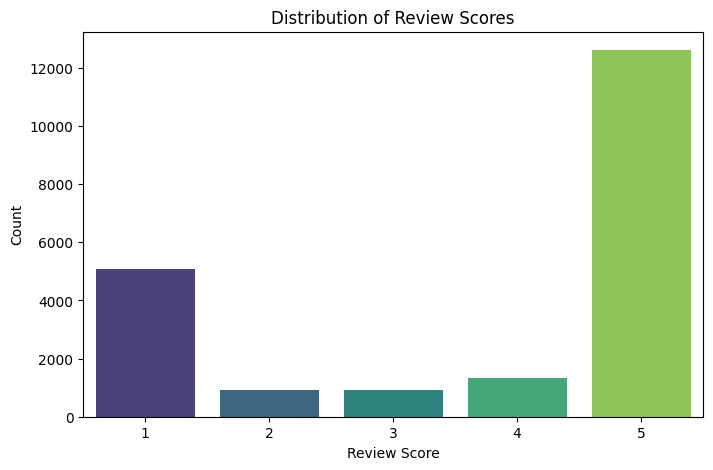

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x='score', data=df_phdrev, palette='viridis', order=sorted(df_phdrev['score'].dropna().unique()))
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.show()

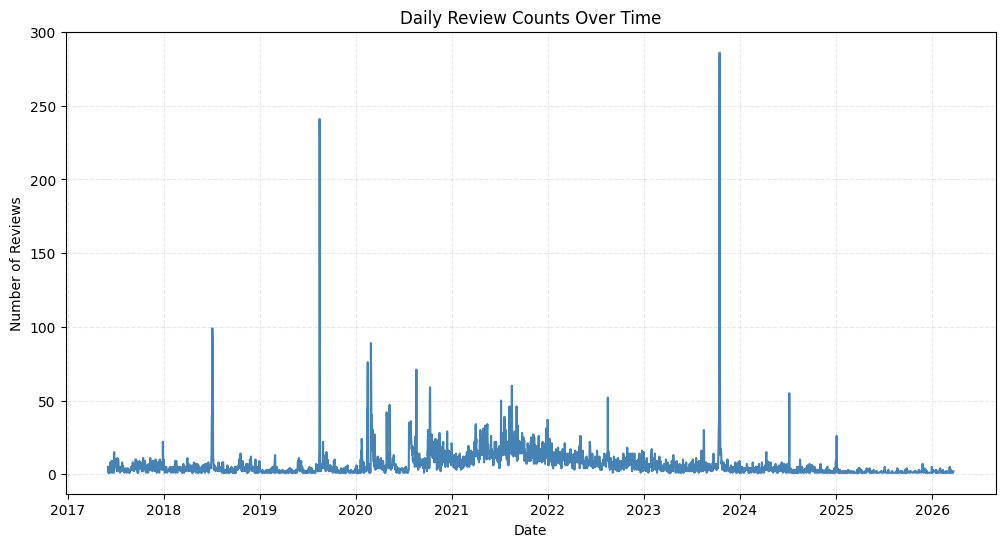

In [17]:
df_phdrev['review_date'] = df_phdrev['at'].dt.date
review_trend = df_phdrev.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot(color='steelblue')
plt.title('Daily Review Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## 8. Review Trends Over Time
Analyzing how the number of reviews changes over time to detect patterns.
```python
# Extract review date
df_phdrev['review_date'] = df_phdrev['at'].dt.date
review_trend = df_phdrev.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Daily Review Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()
```

C:\Users\Frans\AppData\Local\Temp\ipykernel_6836\818612193.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Word', x='Frequency', data=common_words, palette='magma')


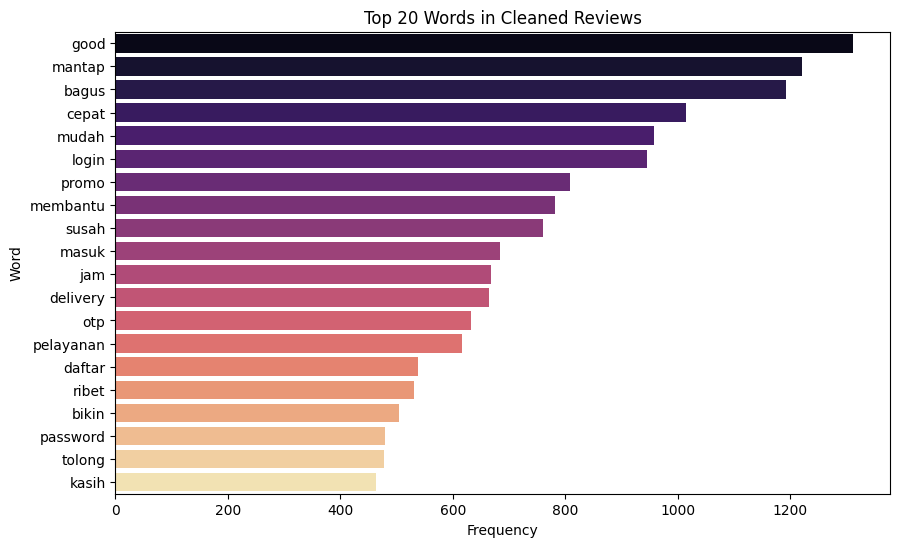

,Word,Frequency
0,good,1312
1,mantap,1221
2,bagus,1193
3,cepat,1014
4,mudah,957
5,login,945
6,promo,808
7,membantu,782
8,susah,760
9,masuk,683


In [18]:
combined_reviews = df_phdrev['cleaned_content'].dropna().str.cat(sep=' ')
word_counts = Counter(combined_reviews.split())
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 6))
sns.barplot(y='Word', x='Frequency', data=common_words, palette='magma')
plt.title('Top 20 Words in Cleaned Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

common_words